# 3.6 human-in-the-loop: 사람이 Agent와 소통하는 방법

- AI는 100%의 정확도를 보장하지 않기 때문에, 경우에 따라 사람의 개입이 필요합니다
- LangGraph의 [`interrupt`](https://langchain-ai.github.io/langgraph/cloud/how-tos/interrupt_concurrent/) 를 사용하여 사람의 개입을 처리할 수 있습니다

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='gpt-4o',
    temperature=0
)

small_llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0
)

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [5]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_secrets_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()


In [6]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x0000022F4D1B0980>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x0000022F4D1B0980>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x0000022F4D1B0980>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x0000022F4D1B0980>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x0000022F4D1B0980>)]

In [7]:
from langchain.agents import load_tools

loaded_tool_list = load_tools(
    ["arxiv"],
)

In [8]:
import os

from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to December 2024',
)

In [9]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [10]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [11]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:
    """
    이 에이전트 함수는 주어진 상태에서 메시지를 가져와
    LLM과 도구를 사용하여 응답 메시지를 생성합니다.

    Args:
        state (MessagesState): 메시지 기록과 요약을 포함하는 상태.

    Returns:
        MessagesState: 응답 메시지를 포함하는 새로운 상태.
    """
    messages = state['messages']
    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

- `interrupt`에는 사용자에게 보여주고자 하는 메시지를 dictionary 형태로 작성합니다

In [12]:
from typing import Literal
from langgraph.types import interrupt, Command

def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    """
    human_review node는 LLM의 도구 호출에 대해 사람의 검토를 요청합니다.

    Args:
        state (AgentState): 메시지 기록을 포함하는 state.

    Returns:
        Command: 다음 node로 이동하기 위한 Command를 반환합니다.
    """
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt({
        'question': '이렇게 진행하면 될까요?',
        'tool_call': tool_call
    })
    review_action = human_review['action'] # action: 'continue' (도구 호출 진행), 'update_args' (도구 호출 인자 수정), 'update_tool' (다른 도구 사용)
    review_data = human_review.get('data', None)
    
    if review_action == 'continue':
        # 에이전트의 판단이 맞다면, 도구를 사용하기 위해 아무것도 수정하지 않고 `tools` 노드로 이동합니다
        return Command(goto='tools')
    
    if review_action == 'update_args':
        # 도구를 더 효율적으로 사용하기 위해 AIMessage의 `tool_calls` 필드를 업데이트합니다
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})
    
    if review_action == 'update_tool':
        # 다른 도구를 사용하기 위해 `ToolMessage`를 업데이트합니다 
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',
            'content': review_data
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})


In [13]:
def summarize_messages(state: AgentState):
    """
    주어진 state의 메시지를 요약합니다.

    Args:
        state (AgentState): 메시지와 요약을 포함하는 state.

    Returns:
        AgentState: 요약된 메시지를 포함하는 딕셔너리.
    """
    messages = state['messages']
    summary = state['summary']
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''
    
    summary = small_llm.invoke(summary_prompt)
    response = llm_with_tools.invoke(messages)
    return {'summary': response.content}

In [14]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState):
    """
    주어진 state에서 오래된 메시지를 삭제합니다.

    Args:
        state (AgentState): 메시지를 포함하는 state.

    Returns:
        AgentState: 삭제된 메시지를 포함하는 새로운 state.
    """
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [15]:
def should_continue(state: MessagesState):
    """
    주어진 state에 따라 다음 단계로 진행할지를 결정합니다.

    Args:
        state (AgentState): 메시지와 도구 호출 정보를 포함하는 state.

    Returns:
        Literal['tools', 'summarize_messages']: 다음 단계로 'tools' 또는 'summarize_messages'를 반환합니다.
    """
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'human_review'
    
    return 'summarize_messages'

- `node`를 추가하고 `edge`로 연결합니다

In [16]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(human_review)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [17]:
from langgraph.graph import START, END


graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['human_review', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

- `interrupt`로 중단된 시점부터 다시 워크플로우를 재개하기 위해 `checkpointer`가 필요합니다

In [18]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph= graph_builder.compile(checkpointer=checkpointer)

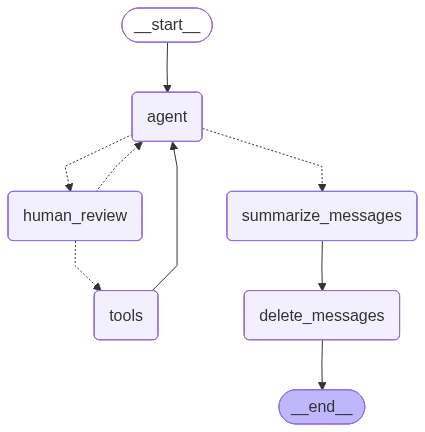

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

query = 'LLM Survey 논문의 내용을 검색해서 요약해주세요'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

LLM Survey 논문의 내용을 검색해서 요약해주세요
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_EerRoDWMjEDFucT9RHQiaGw8)
 Call ID: call_EerRoDWMjEDFucT9RHQiaGw8
  Args:
    query: LLM Survey


In [21]:
for chunk in graph.stream(
    Command(resume={"action": "update_tool", "data": "arxiv말고 web에서 검색해주세요"}),
    config,
    stream_mode="updates",
):
    print(chunk)

{'human_review': {'messages': [{'tool_call_id': 'call_EerRoDWMjEDFucT9RHQiaGw8', 'name': 'arxiv', 'role': 'tool', 'content': 'arxiv말고 web에서 검색해주세요'}]}}
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_E44TSR7YKdganFK3zkXL0lcL', 'function': {'arguments': '{"query":"LLM Survey paper summary"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 779, 'total_tokens': 800, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a1ddba3226', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-cc68faec-e1f9-450d-9959-c36457516dd7-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'LLM Survey paper summary'}, 'id': 'call_E44T

In [22]:
for chunk in graph.stream(
    Command(resume={"action": "continue"}),
    config,
    stream_mode="updates",
):
    print(f'chunk == {chunk}')

chunk == {'human_review': None}


c:\Users\dev-euna\Desktop\AI_AGENT_STUDY\langgraph-agent\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:64: UserWarning: 'api' backend is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


chunk == {'tools': {'messages': [ToolMessage(content='This article summarizes notable LLM-related papers as of 2026-03-01. Papers are automatically collected from arXiv, Semantic Scholar, and Hugging Face Daily Papers, with Japanese summaries generated via the Claude API. 🔰 LLM Survey Papers Collection This repo contains a category wise collection of 200+ LLM survey papers. In this paper, we survey recent advances in Reinforcement Learning (RL) for reasoning with Large Language Models (LLMs). RL has achieved remarkable success in advancing the frontier of LLM capabilities, particularly in addressing complex logical tasks such as mathematics and coding. Deploying LLMs without human supervision and evaluation can lead to significant errors. This post outlines the fundamentals of LLM evaluation for text summarization in high-stakes applications. The latest in LLM research with a hand-curated, topic-organized list of over 200 research papers from 2025.', name='duckduckgo_search', id='75ff5

In [23]:
graph.get_state(config).values['messages']

[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_E44TSR7YKdganFK3zkXL0lcL', 'function': {'arguments': '{"query":"LLM Survey paper summary"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 779, 'total_tokens': 800, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a1ddba3226', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-cc68faec-e1f9-450d-9959-c36457516dd7-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'LLM Survey paper summary'}, 'id': 'call_E44TSR7YKdganFK3zkXL0lcL', 'type': 'tool_call'}], usage_metadata={'input_tokens': 779, 'output_tokens': 21, 'total_tokens': 800, 'input_token_details': {'audio': 0, 'cache_read': 